# 35 — EDA: ICWSM & JCDL Award Data

Exploratory analysis of `icwsm_jcdl_awards_raw.csv` produced by notebook `01b`.  

Sections:
1. Load & sanity check  
2. Coverage — records per year × conference  
3. OpenAlex match rate by year and award type  
4. Citation distribution (matched papers only)  
5. Top-10 cited papers per award type  
6. Missing data audit — unmatched papers table  


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

pd.set_option('display.max_colwidth', 90)

df = pd.read_csv('../data/raw/icwsm_jcdl_awards_raw.csv')
df['matched'] = df['openalex_id'].notna() & (df['openalex_id'] != '')
df['cited_by_count'] = pd.to_numeric(df['cited_by_count'], errors='coerce')

print(f'Total records : {len(df)}')
print(f'Matched to OA : {df.matched.sum()} ({df.matched.mean():.1%})')
print(f'Year range    : {df.year.min()} – {df.year.max()}')
print()
df.dtypes

Total records : 112
Matched to OA : 60 (53.6%)
Year range    : 1998 – 2025



year                int64
conference         object
paper_title        object
paper_url          object
authors            object
award_type         object
award_year          int64
openalex_id        object
openalex_title     object
cited_by_count    float64
matched              bool
dtype: object

## 1. Award type breakdown

In [2]:
breakdown = (
    df.groupby(['conference', 'award_type'])
      .agg(count=('paper_title', 'count'),
           matched=('matched', 'sum'),
           median_cites=('cited_by_count', 'median'))
      .reset_index()
)
breakdown['match_rate'] = (breakdown['matched'] / breakdown['count']).map('{:.0%}'.format)
breakdown

,conference,award_type,count,matched,median_cites,match_rate
0,ICWSM,Best Paper,32,0,NaN,0%
1,ICWSM,Test of Time,5,0,NaN,0%
2,JCDL,Best Demonstration,1,1,2.0,100%
3,JCDL,Best International Paper,2,1,71.0,50%
4,JCDL,Best Poster,17,12,2.0,71%
5,JCDL,Best Resource Paper,1,1,0.0,100%
6,JCDL,Best Short Paper,3,3,0.0,100%
7,JCDL,Best Student Paper,22,19,16.0,86%
8,JCDL,Vannevar Bush Best Paper,29,23,10.0,79%


## 2. Coverage — records per year × conference

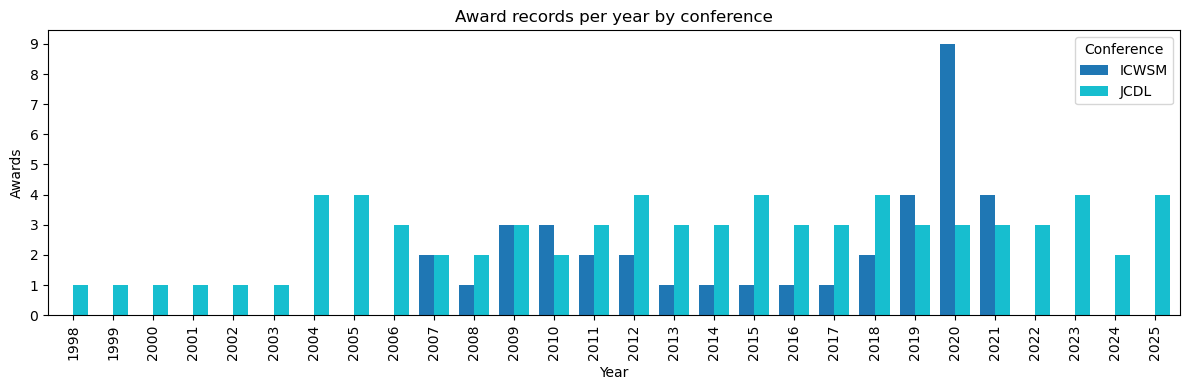

In [3]:
pivot = df.groupby(['year', 'conference']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
pivot.plot(kind='bar', ax=ax, width=0.75, colormap='tab10')
ax.set_xlabel('Year')
ax.set_ylabel('Awards')
ax.set_title('Award records per year by conference')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(title='Conference')
plt.tight_layout()
plt.savefig('../data/raw/eda_coverage_per_year.png', dpi=150)
plt.show()

## 3. OpenAlex match rate by year

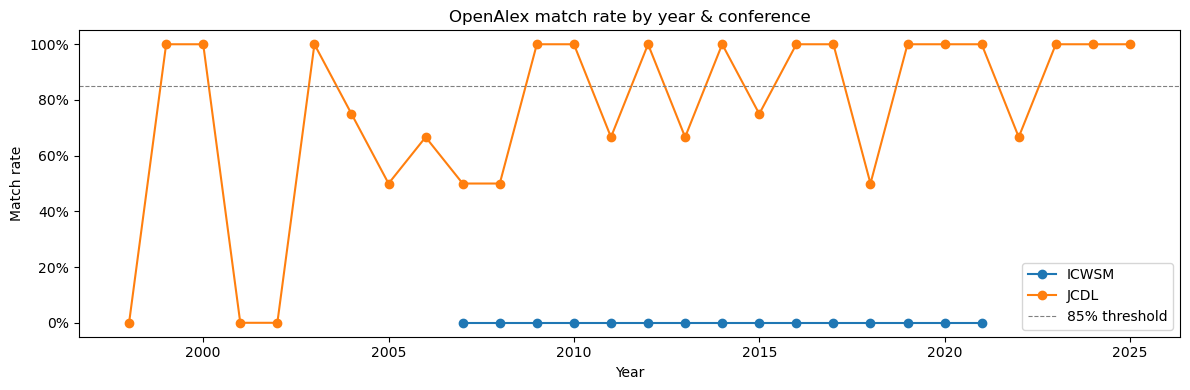

In [4]:
match_by_year = (
    df.groupby(['year', 'conference'])['matched']
      .agg(['sum', 'count'])
      .reset_index()
)
match_by_year['rate'] = match_by_year['sum'] / match_by_year['count']

fig, ax = plt.subplots(figsize=(12, 4))
for conf, grp in match_by_year.groupby('conference'):
    ax.plot(grp['year'], grp['rate'], marker='o', label=conf)
ax.axhline(0.85, color='grey', linestyle='--', linewidth=0.8, label='85% threshold')
ax.set_xlabel('Year')
ax.set_ylabel('Match rate')
ax.set_title('OpenAlex match rate by year & conference')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.savefig('../data/raw/eda_match_rate_by_year.png', dpi=150)
plt.show()

## 4. Citation distribution (matched papers)

                                     count  mean   std   min   25%   50%   75%    max
conference award_type                                                                
JCDL       Best Demonstration          1.0   2.0   NaN   2.0   2.0   2.0   2.0    2.0
           Best International Paper    1.0  71.0   NaN  71.0  71.0  71.0  71.0   71.0
           Best Poster                12.0   4.1   4.8   0.0   1.5   2.0   5.5   14.0
           Best Resource Paper         1.0   0.0   NaN   0.0   0.0   0.0   0.0    0.0
           Best Short Paper            3.0   3.3   5.8   0.0   0.0   0.0   5.0   10.0
           Best Student Paper         19.0  26.8  27.5   1.0   7.5  16.0  35.5  115.0
           Vannevar Bush Best Paper   23.0  34.3  47.5   0.0   4.0  10.0  50.5  183.0


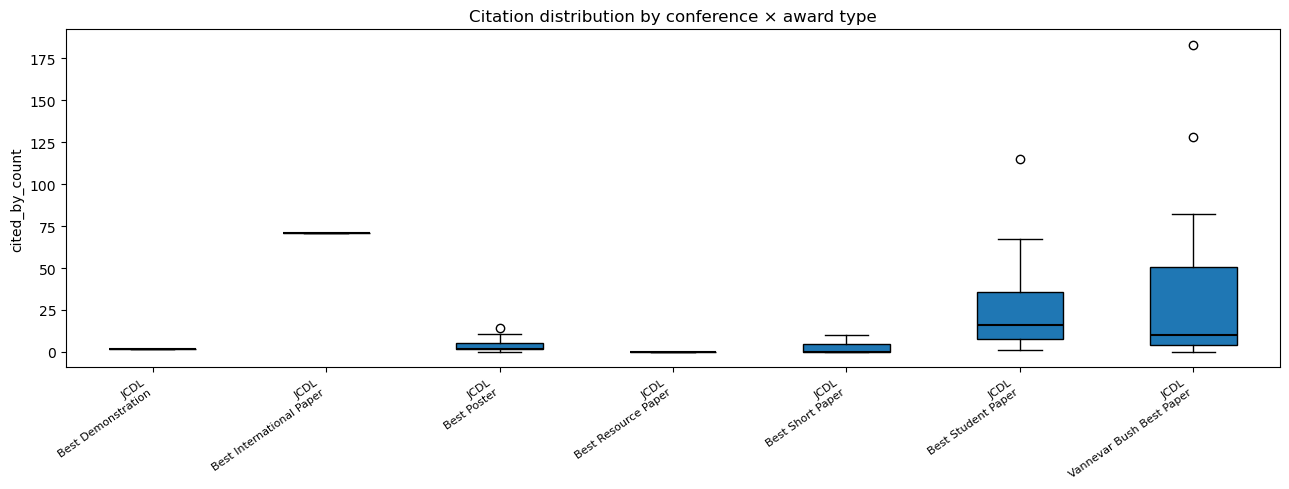

In [5]:
matched = df[df['matched'] & df['cited_by_count'].notna()].copy()

# Summary stats
stats = (
    matched.groupby(['conference', 'award_type'])['cited_by_count']
           .describe(percentiles=[.25, .5, .75])
           .round(1)
)
print(stats.to_string())

# Box plots per award_type, coloured by conference
award_types = matched['award_type'].unique()
fig, ax = plt.subplots(figsize=(13, 5))

labels, data_sets = [], []
for conf in ['ICWSM', 'JCDL']:
    sub = matched[matched['conference'] == conf]
    for atype in sorted(sub['award_type'].unique()):
        vals = sub[sub['award_type'] == atype]['cited_by_count'].dropna().values
        if len(vals) > 0:
            data_sets.append(vals)
            labels.append(f'{conf}\n{atype}')

ax.boxplot(data_sets, labels=labels, vert=True, patch_artist=True,
           medianprops=dict(color='black', linewidth=1.5))
ax.set_ylabel('cited_by_count')
ax.set_title('Citation distribution by conference × award type')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../data/raw/eda_citation_boxplot.png', dpi=150)
plt.show()

## 5. Top-10 cited papers per award type

In [6]:
FOCUS_AWARDS = ['Vannevar Bush Best Paper', 'Best Paper', 'Test of Time', 'Best Student Paper']

for atype in FOCUS_AWARDS:
    sub = matched[matched['award_type'] == atype].nlargest(10, 'cited_by_count')
    if sub.empty:
        continue
    print(f"\n=== {atype} — Top 10 by citations ==={chr(10)}")
    display(sub[['year', 'conference', 'paper_title', 'cited_by_count']].reset_index(drop=True))


=== Vannevar Bush Best Paper — Top 10 by citations ===



,year,conference,paper_title,cited_by_count
0,2004,JCDL,Automatic organization for digital photographs with geographic coordinates,183.0
1,2013,JCDL,Exploiting Potential Citation Papers in Scholarly Paper Recommendation,128.0
2,1999,JCDL,Towards a digital library of popular music,82.0
3,2003,JCDL,How fast is too fast? Evaluating fast forward surrogates for digital video,80.0
4,2000,JCDL,Effects of annotations on student readers and writers,72.0
5,2012,JCDL,Modeling and exploiting heterogeneous bibliographic networks for expertise ranking,62.0
6,2005,JCDL,Developing practical automatic metadata assignment and evaluation tools for internet r...,39.0
7,2009,JCDL,Automatically characterizing resource quality for educational digital libraries,38.0
8,2016,JCDL,Comparing Published Scientific Journal Articles to Their Pre-print Versions,36.0
9,2019,JCDL,Do Authors Deposit on Time? Tracking Open Access Policy Compliance,12.0



=== Best Student Paper — Top 10 by citations ===



,year,conference,paper_title,cited_by_count
0,2010,JCDL,Improving mood classification in music digital libraries by combining lyrics and audio,115.0
1,2013,JCDL,Automatic tag recommendation for metadata annotation using probabilistic topic modeling,67.0
2,2014,JCDL,Not All Mementos Are Created Equal: Measuring The Impact Of Missing Resources,44.0
3,2007,JCDL,Modeling personal and social network context for event annotation in images,43.0
4,2016,JCDL,Evaluating the Quality of Educational Answers in Community Question-Answering,40.0
5,2017,JCDL,Matrix-based News Aggregation: Exploring Different News Perspectives,31.0
6,2009,JCDL,Improving optical character recognition through efficient multiple system alignment,29.0
7,2012,JCDL,Content-based layouts for exploratory metadata search in scientific research data,27.0
8,2004,JCDL,The effectiveness of automatically structured queries in digital libraries,25.0
9,2011,JCDL,Archiving the web using page changes pattern: a case study,16.0


## 6. Missing data audit — unmatched papers

In [7]:
unmatched = df[~df['matched']].copy()
print(f'Unmatched records: {len(unmatched)}')
print()

# By year — helps spot systematic gaps (e.g. old papers pre-2005)
print('Unmatched by year:')
print(unmatched.groupby('year').size().to_string())
print()

# Full table
display(unmatched[['year', 'conference', 'award_type', 'paper_title', 'authors']].reset_index(drop=True))

Unmatched records: 52

Unmatched by year:
year
1998    1
2001    1
2002    1
2004    1
2005    2
2006    1
2007    3
2008    2
2009    3
2010    3
2011    3
2012    2
2013    2
2014    1
2015    2
2016    1
2017    1
2018    4
2019    4
2020    9
2021    4
2022    1



,year,conference,award_type,paper_title,authors
0,2007,ICWSM,Best Paper,TagAssist: Automatic Tag Suggestion for Blog Posts,"Sanjay Sood, Sara Owsley, Kristian Hammond and Larry Birnbaum"
1,2008,ICWSM,Best Paper,Wikipedian Self-Governance in Action: Motivating the Policy Lens,"Ivan Beschastnikh, Travis Kriplean, DavidW. McDonald"
2,2009,ICWSM,Best Paper,Gesundheit! Modeling Contagion Through Facebook News Feed,"Eric Sun, Itamar Rosenn, Cameron Marlow, Thomas Lento"
3,2009,ICWSM,Best Paper,"Motivational, Structural and Tenure Factors that Impact Online Community Photo Sharing","Oded Nov, Mor Naaman, Chen Ye"
4,2010,ICWSM,Best Paper,ePluribus : Ethnicity on Social Networks,"Jonathan Chang, Itamar Rosenn, Lars Backstrom, Cameron Marlow"
5,2010,ICWSM,Best Paper,The Social Dynamics of Economic Activity in a Virtual World,"Eytan Bakshy, Matthew Simmons, David Huffaker, ChunYuen Teng, Lada Adamic"
6,2011,ICWSM,Best Paper,4chan and /b/: An Analysis of Anonymity and Ephemerality in a Large Online Community,"Michael Bernstein, AndrÃ©s Monroy-HernÃ¡ndez, Drew Harry, Paul AndrÃ©, Katrina Panovic..."
7,2012,ICWSM,Best Paper,The Livehoods Project: Utilizing Social Media to Understand the Dynamics of a City,"Justin Cranshaw, Raz Schwartz, Jason Hong, and Norman Sadeh"
8,2012,ICWSM,Best Paper,The Emergence of Conventions in Online Social Networks,"Farshad Kooti, Haeryun Yang, Meeyoung Cha, Krishna P. Gummadi, Winter A. Mason"
9,2013,ICWSM,Best Paper,Booming Up the Long Tails: Discovering Potentially Contributive Users in Community-Bas...,"Juyup Sung, Jae-Gil Lee, Uichin Lee"


## 7. Citation distribution over time (Vannevar Bush + ICWSM Best Paper)

Scatter of `cited_by_count` vs `year` for the two main best-paper awards — useful to see if older papers have had more time to accumulate citations.

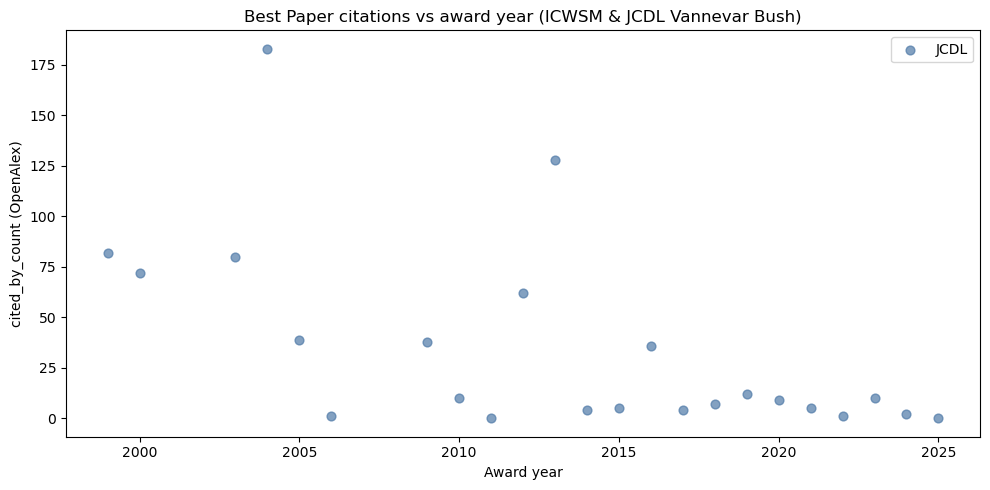

In [8]:
main_awards = matched[matched['award_type'].isin(['Vannevar Bush Best Paper', 'Best Paper'])].copy()

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'ICWSM': '#e15759', 'JCDL': '#4e79a7'}
for conf, grp in main_awards.groupby('conference'):
    ax.scatter(grp['year'], grp['cited_by_count'],
               color=colors.get(conf, 'grey'), alpha=0.7, label=conf, s=40)

ax.set_xlabel('Award year')
ax.set_ylabel('cited_by_count (OpenAlex)')
ax.set_title('Best Paper citations vs award year (ICWSM & JCDL Vannevar Bush)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/raw/eda_bestpaper_citations_over_time.png', dpi=150)
plt.show()